# Pondview pool: hourly arrival forecasting -- findings

A narrative walkthrough of a small forecaster for a community pool. The target is
**family arrivals per hour**: the count of sign-in lines in each open hour. It is
**not occupancy** -- the pool records arrivals on paper sign-in sheets but never
records departures, so how many families are present at any moment is unknown and
unmodeled. Everything below concerns *arrivals*, not people in the water.

The model, baseline, and feature list are imported from `src/train.py`, so this
notebook and the training script cannot disagree.

In [1]:
import sys
from pathlib import Path

# Make `src` importable and locate the data regardless of where this is launched from.
REPO = Path.cwd()
if REPO.name == "notebooks":
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (8, 4),
    "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True,
})
BLUE, ORANGE, RED = "#2b6cb0", "#dd8452", "#c44e52"

# One source of truth for the modeling logic.
from src.train import make_model, baseline_predict, FEATURES, TARGET

df = pd.read_csv(REPO / "data" / "processed" / "hourly.csv", parse_dates=["datetime"])
df["date"] = df["datetime"].dt.normalize()

n_days = df["date"].nunique()
zeros = (df[TARGET] == 0)
print(f"{len(df)} observed hours across {n_days} days "
      f"({df['datetime'].min().date()} to {df['datetime'].max().date()})")
print(f"total arrivals: {int(df[TARGET].sum())}   mean: {df[TARGET].mean():.2f}/hour   "
      f"zero-arrival hours: {int(zeros.sum())} ({zeros.mean():.1%})")
print(f"model features ({len(FEATURES)}): {FEATURES}")
df.head()

197 observed hours across 24 days (2026-07-08 to 2026-08-04)
total arrivals: 1166   mean: 5.92/hour   zero-arrival hours: 39 (19.8%)
model features (7): ['hour', 'is_weekend', 'temperature_2m', 'precipitation', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m']


,datetime,arrivals,hour,day_of_week,is_weekend,temperature_2m,precipitation,relative_humidity_2m,cloud_cover,wind_speed_10m,date
0,2026-07-08 10:00:00,8,10,2,0,70.9,0.0,78,0,5.5,2026-07-08
1,2026-07-08 11:00:00,13,11,2,0,73.2,0.0,74,0,5.6,2026-07-08
2,2026-07-08 12:00:00,14,12,2,0,75.4,0.0,70,0,4.2,2026-07-08
3,2026-07-08 13:00:00,11,13,2,0,77.1,0.0,67,0,3.5,2026-07-08
4,2026-07-08 14:00:00,8,14,2,0,80.1,0.0,55,0,4.1,2026-07-08


## Arrivals by hour of day

The strongest, most repeatable pattern in the data: arrivals build through the day to a
late-afternoon peak and fall off sharply in the evening. Getting this hour-of-day shape
right is most of the job.

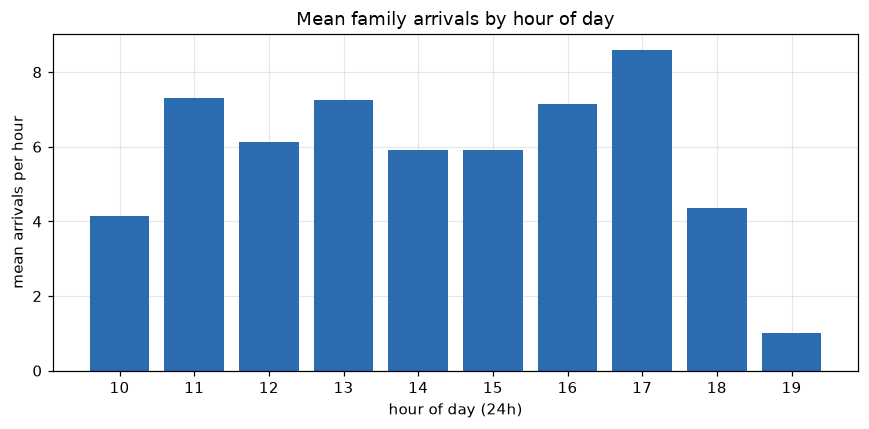

In [2]:
by_hour = df.groupby("hour")[TARGET].mean()
fig, ax = plt.subplots()
ax.bar(by_hour.index, by_hour.values, color=BLUE)
ax.set_xlabel("hour of day (24h)")
ax.set_ylabel("mean arrivals per hour")
ax.set_title("Mean family arrivals by hour of day")
ax.set_xticks(by_hour.index)
plt.tight_layout()
plt.show()

## Arrivals by day of week

Weekend hours run busier than weekday hours (weekends in orange). Beyond the
weekend/weekday split, the day-to-day pattern is noisy -- there are only a few weeks
here, so a full day-of-week feature mostly fits noise (the ablation in `src/ablation.py`
confirms this, which is why the model uses only a weekend flag).

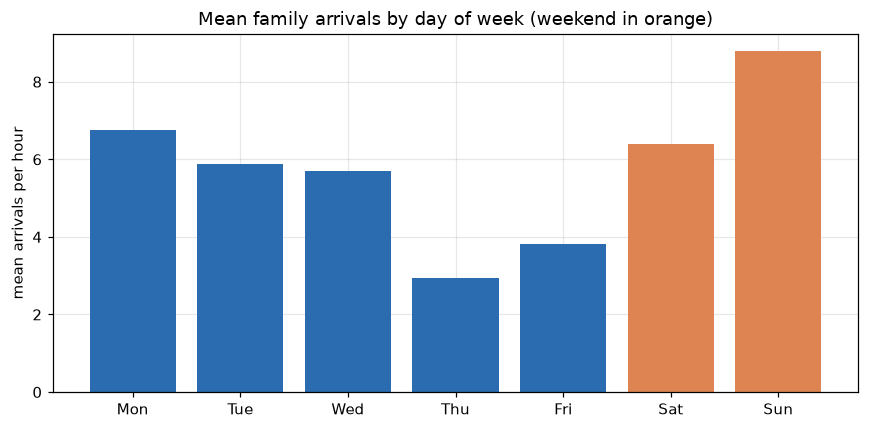

In [3]:
DOW = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_dow = df.groupby("day_of_week")[TARGET].mean().reindex(range(7))
fig, ax = plt.subplots()
ax.bar(range(7), by_dow.values, color=[BLUE if d < 5 else ORANGE for d in range(7)])
ax.set_xticks(range(7))
ax.set_xticklabels(DOW)
ax.set_ylabel("mean arrivals per hour")
ax.set_title("Mean family arrivals by day of week (weekend in orange)")
plt.tight_layout()
plt.show()

## Arrivals versus temperature

Temperature sorts busy from quiet hours only weakly. The clearly empty hours are the
rainy ones (red), not the cool ones -- an early sign that rain, not heat, carries what
little weather signal this window holds.

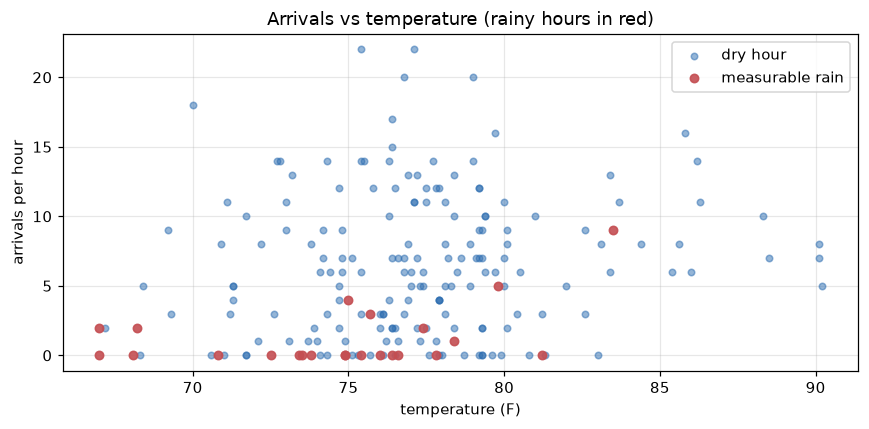

In [4]:
wet = df["precipitation"] >= 0.01
fig, ax = plt.subplots()
ax.scatter(df.loc[~wet, "temperature_2m"], df.loc[~wet, TARGET],
           s=18, alpha=0.5, color=BLUE, label="dry hour")
ax.scatter(df.loc[wet, "temperature_2m"], df.loc[wet, TARGET],
           s=30, alpha=0.9, color=RED, label="measurable rain")
ax.set_xlabel("temperature (F)")
ax.set_ylabel("arrivals per hour")
ax.set_title("Arrivals vs temperature (rainy hours in red)")
ax.legend()
plt.tight_layout()
plt.show()

## Arrivals across the season

Daily turnout swings widely. The breaks in the line are unobserved days -- the pool was
closed, or its sign-in sheet was lost. Those gaps are exactly why the hour grid is built
from the verified day log rather than from a continuous calendar: we only model days we
actually observed.

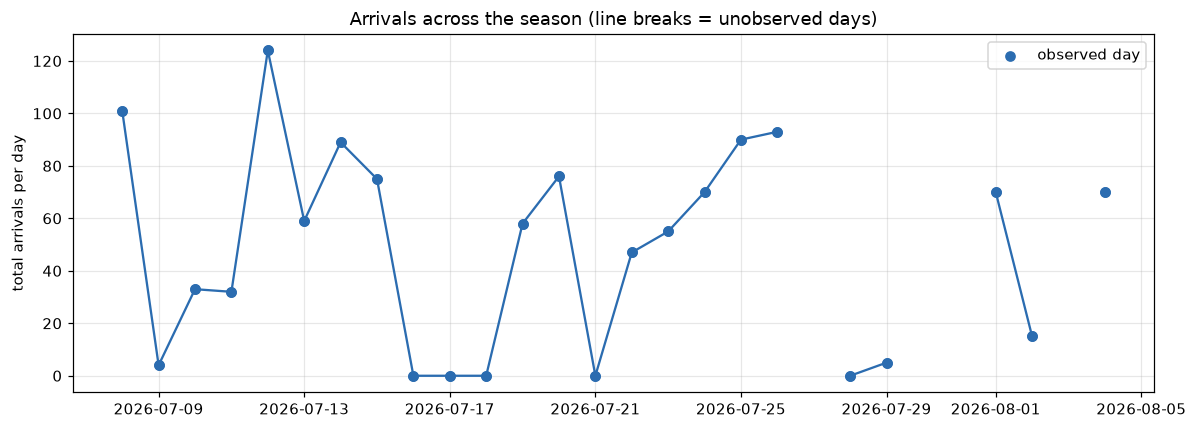

In [5]:
daily = df.groupby("date")[TARGET].sum()
full = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
daily_full = daily.reindex(full)  # unobserved days -> NaN -> the line breaks
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(daily_full.index, daily_full.values, color=BLUE, marker="o", linewidth=1.5)
ax.scatter(daily.index, daily.values, color=BLUE, zorder=3, label="observed day")
ax.set_ylabel("total arrivals per day")
ax.set_title("Arrivals across the season (line breaks = unobserved days)")
ax.legend()
plt.tight_layout()
plt.show()

## The weather-variance constraint

Before asking how much weather can help, we have to ask how much weather *varies*. In a
few weeks of mid-summer, temperature barely moves, so the usable signal is rain -- and
measurable rain is rare. This number bounds how much any weather model can add.

In [6]:
measurable = df["precipitation"] >= 0.01
print(f"hours with measurable precipitation (>= 0.01 in): "
      f"{int(measurable.sum())} of {len(df)} ({measurable.mean():.1%})")
print(f"mean arrivals -- dry hours: {df.loc[~measurable, TARGET].mean():.2f}   "
      f"rainy hours: {df.loc[measurable, TARGET].mean():.2f}")
print("Implication: rain hits turnout hard, but it is rare enough that weather features "
      "can only help modestly -- and any gain must be read against that thin sample.")

hours with measurable precipitation (>= 0.01 in): 23 of 197 (11.7%)
mean arrivals -- dry hours: 6.54   rainy hours: 1.22
Implication: rain hits turnout hard, but it is rare enough that weather features can only help modestly -- and any gain must be read against that thin sample.


## Baseline first

Before any model, a baseline: mean arrivals by (hour, is_weekend), fit on the training
fold only. Evaluation is **leave-one-day-out** -- each day is held out once. We split by
day, never by row, because hours in the same afternoon share weather and crowd, so a
row-level split would leak that day's conditions into training.

In [7]:
days = sorted(df["date"].unique())
df["pred_baseline"] = np.nan
base_fold_mae = []
for day in days:
    held = df["date"] == day
    train, test = df[~held], df[held]
    pred = baseline_predict(train, test)          # fit on train fold only
    df.loc[held, "pred_baseline"] = pred
    base_fold_mae.append(mean_absolute_error(test[TARGET], pred))
base_fold_mae = np.array(base_fold_mae)
print(f"baseline (hour x is_weekend mean), {len(days)} folds")
print(f"  leave-one-day-out MAE: {base_fold_mae.mean():.3f} +/- {base_fold_mae.std():.3f} arrivals/hour")

baseline (hour x is_weekend mean), 24 folds
  leave-one-day-out MAE: 4.238 +/- 1.945 arrivals/hour


## The model, next to the baseline

A shallow gradient-boosting regressor (`make_model()` from `src/train.py`) on
`hour, is_weekend` plus five weather variables, same leave-one-day-out split. A model
that could not beat the baseline lookup would not be worth deploying, so we always show
them together.

In [8]:
df["pred_model"] = np.nan
model_fold_mae = []
for day in days:
    held = df["date"] == day
    train, test = df[~held], df[held]
    model = make_model()
    model.fit(train[FEATURES], train[TARGET])
    pred = np.clip(model.predict(test[FEATURES]), 0, None)   # arrivals can't be negative
    df.loc[held, "pred_model"] = pred
    model_fold_mae.append(mean_absolute_error(test[TARGET], pred))
model_fold_mae = np.array(model_fold_mae)

improvement = (base_fold_mae.mean() - model_fold_mae.mean()) / base_fold_mae.mean() * 100
print(f"baseline LOO MAE: {base_fold_mae.mean():.3f} +/- {base_fold_mae.std():.3f}")
print(f"model    LOO MAE: {model_fold_mae.mean():.3f} +/- {model_fold_mae.std():.3f}")
print(f"improvement over baseline: {improvement:+.1f}%")

baseline LOO MAE: 4.238 +/- 1.945
model    LOO MAE: 2.908 +/- 1.630
improvement over baseline: +31.4%


## Where the model wins

Breaking the out-of-fold error down by condition shows *where* the model earns its
margin -- computed on genuinely held-out predictions, pooled across folds.

In [9]:
err_b = (df[TARGET] - df["pred_baseline"]).abs()
err_m = (df[TARGET] - df["pred_model"]).abs()
seg = df.assign(abs_err_baseline=err_b, abs_err_model=err_m)
seg["temp_bucket"] = pd.qcut(seg["temperature_2m"], 3, labels=["cool", "mild", "warm"])

def breakdown(name, group_col, labelmap=None):
    rows = []
    for label, g in seg.groupby(group_col, observed=True):
        who = labelmap.get(label, label) if labelmap else str(label)
        b, m = g["abs_err_baseline"].mean(), g["abs_err_model"].mean()
        rows.append({"segment": who, "n": len(g),
                     "baseline_MAE": round(b, 3), "model_MAE": round(m, 3),
                     "delta": round(b - m, 3)})
    return pd.DataFrame(rows)

by_wknd = breakdown("weekend", "is_weekend", {0: "weekday", 1: "weekend"})
by_temp = breakdown("temperature", "temp_bucket")
print(by_wknd.to_string(index=False))
print()
print(by_temp.to_string(index=False))

best = pd.concat([by_wknd, by_temp], ignore_index=True).sort_values("delta", ascending=False).iloc[0]
print(f"\nThe model beats the baseline most on {best['segment']} hours "
      f"(MAE {best['delta']:.2f} families/hour lower than the baseline).")

segment   n  baseline_MAE  model_MAE  delta
weekday 134         3.575      2.880  0.696
weekend  63         4.495      3.223  1.273

segment  n  baseline_MAE  model_MAE  delta
   cool 66         3.782      2.382  1.400
   mild 65         4.112      3.014  1.098
   warm 66         3.718      3.573  0.145

The model beats the baseline most on cool hours (MAE 1.40 families/hour lower than the baseline).


## What the missingness tells us, and what it doesn't

The most important modeling decision here is which hours count as observations. The grid
is built from the verified day log, so an open hour with zero arrivals is kept as a real
zero -- and those zeros carry most of the bad-weather signal. Days the pool was closed,
or whose sheet was lost, are excluded, because we genuinely cannot say what happened.
That is informative missingness handled honestly: we neither drop the quiet days that
make the model useful, nor invent turnout for days we never recorded.

Read the numbers with the limits in mind. This is **one site** over **a few weeks of one
summer**. Mid-summer temperature barely varies, so the usable weather signal is mostly a
handful of rainy hours; the model beats a strong time-of-day baseline by a real but
**modest** margin, and the ablation shows that margin comes from weather, not the
calendar. It forecasts **arrivals, never occupancy**. None of it is claimed to generalize
beyond this pool and this season.